In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 66.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [ ]:
generator = nn.Sequential(
    nn.Linear(100,256),
    nn.ReLU(),
    nn.Linear(256,512),
    nn.ReLU(),
    nn.Linear(512,1024),
    nn.ReLU(),
    nn.Linear(1024,784),
    nn.Tanh()
)

In [ ]:
discriminator = nn.Sequential(
    nn.Linear(784,512),
    nn.LeakyReLU(0.2),
    nn.Linear(512,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,1),
    nn.Sigmoid()
)

In [ ]:
loss_function = nn.BCELoss()

In [ ]:
optimizer_generator = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002
)

optimizer_discriminator = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)

In [ ]:
epochs = 10

for epoch in range(epochs):

    for images,labels in dataloader:

        real_images = images.view(-1,784)

        real_labels = torch.ones(real_images.size(0),1)
        fake_labels = torch.zeros(real_images.size(0),1)

        outputs = discriminator(real_images)
        loss_real = loss_function(outputs,real_labels)

        noise = torch.randn(real_images.size(0),100)
        fake_images = generator(noise)

        outputs = discriminator(fake_images.detach())
        loss_fake = loss_function(outputs,fake_labels)

        loss_discriminator = loss_real + loss_fake

        optimizer_discriminator.zero_grad()
        loss_discriminator.backward()
        optimizer_discriminator.step()

        noise = torch.randn(real_images.size(0),100)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        loss_generator = loss_function(outputs,real_labels)

        optimizer_generator.zero_grad()
        loss_generator.backward()
        optimizer_generator.step()

    print("Epoch:",epoch,"Generator Loss:",loss_generator.item(),"Discriminator Loss:",loss_discriminator.item())

Epoch: 0 Generator Loss: 5.954799175262451 Discriminator Loss: 0.05623356252908707
Epoch: 1 Generator Loss: 4.196893692016602 Discriminator Loss: 1.1113841533660889
Epoch: 2 Generator Loss: 2.1464388370513916 Discriminator Loss: 0.7769961357116699
Epoch: 3 Generator Loss: 3.4867875576019287 Discriminator Loss: 0.40428319573402405
Epoch: 4 Generator Loss: 3.1963438987731934 Discriminator Loss: 0.2141532599925995
Epoch: 5 Generator Loss: 3.7585525512695312 Discriminator Loss: 0.4819808006286621
Epoch: 6 Generator Loss: 5.783203125 Discriminator Loss: 0.5697464942932129
Epoch: 7 Generator Loss: 3.208303451538086 Discriminator Loss: 0.3794306218624115
Epoch: 8 Generator Loss: 3.0558903217315674 Discriminator Loss: 0.7844176292419434
Epoch: 9 Generator Loss: 2.43078875541687 Discriminator Loss: 0.7860702276229858


In [ ]:
noise = torch.randn(16,100)
generated_images = generator(noise)
generated_images = generated_images.view(16,28,28)
generated_images = generated_images.detach().numpy()

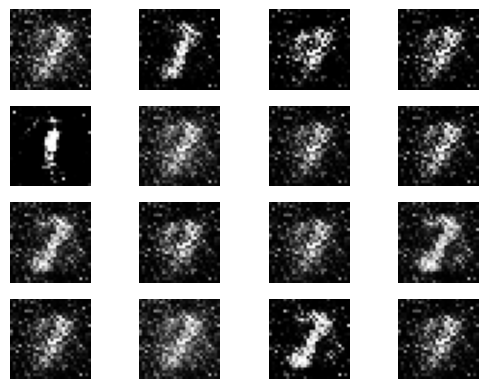

In [ ]:
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i],cmap='gray')
    plt.axis('off')
plt.show()